In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    # plt.style.use('belle2_serif')
    plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark, lumi
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

Welcome to JupyROOT 6.26/04


In [2]:
def load_root_files(dir_list, tags, tree, cut, variables, bdt_cut):
    # file_map = {tag: [] for tag in tags}
    # for tag in tags:
    #     for d in dir_list:
    #         path = os.path.join(d, f"weighted_{tag}.BCS.root")
    #         if os.path.exists(path):
    #             file_map[tag].append(path)
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            # pattern = os.path.join(d,f"{tree}", "ref", "min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
            pattern = os.path.join(d,f"{tree}", "ref", "no_bdt_no_pi0veto", "weighted", f"weighted_{tag}*.root")
            # print(pattern)
            matched_files = glob.glob(pattern)
            matched_files.sort()
            file_map[tag].extend(matched_files)
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")
        
    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        dataframes[tag] = df.query(cut)
    return dataframes

def load_data_files(data_dir_list, tree, cut, variables, bdt_cut):
    dfs = []
    for d in data_dir_list:
        # print(os.path.join(d, f"{tree}","min_unc_search", f"{bdt_cut}", "*BDT.root"))
        for file in glob.glob(os.path.join(d, f"{tree}", "ref", "no_bdt_no_pi0veto", f"{bdt_cut}", "*BDT.root")):
        # for file in glob.glob(os.path.join(d, f"{tree}", "ref", f"{bdt_cut}", "*BDT.root")):
            print(file)
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)


def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, nbins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, nbins + 1)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    data_hist, _ = np.histogram(data_df[var], bins=xbins)
    ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    # watermark(t="",logo="Preliminary",px=0.84, py=0.82, fontsize=14)
    # lumi(l="$428\; \mathrm{fb}^{-1}$", px=0.78, py=0.90)    
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(rf"Entries / ({bin_width:.4f} $\mathrm{{GeV/c^2}}$)")
    # ax.legend(loc="upper left", ncol=2, prop={'size':13})
    ax.legend(loc="best", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


In [3]:
# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

In [25]:
# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_gg"
# cut = "Dp_M>0 & rank_Dp_chiProb==1"
# cut = "Dp_M>0 & rank_Dp_chiProb==1 &  dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011"
cut = "Dp_M>0 & rank_Dp_chiProb==1 &  dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011 & BDT > 0.86"
# variables = ["Dp_M", "ds_weight", "rank_Dp_chiProb"]
variables = ["Dp_M", "rank_Dp_chiProb", "ROE_Mgg_mask", "ROE_Mgg_mask_2", "etapip_gg_Eta_M_bf", "etapip_gg_Eta_InvM_bf", "BDT", "dM_pi0_mask_nonan", "dM_pi0_mask_2_nonan"]

# var = ["Dp_M","rank_Dp_chiProb"]

# bdt_cut="0.86"
bdt_cut=""


# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

# mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
# mc_dirs = [
#     f"{mc_base}/15rd_jae_e7_18_4S_v3",
#     f"{mc_base}/15rd_jae_e20_b26_v1",
#     f"{mc_base}/15rd_jae_e20_e26_4S_v2",
#     f"{mc_base}/15rd_jae_e21_5S_scan_v1",
#     f"{mc_base}/15rd_jae_mori_off_v1",
# ]
mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260429_nopi0veto"

mc_dirs = [
    f"{mc_base}/15rd_Etap_e7_18_4S_v3",
    f"{mc_base}/15rd_Etap_e20_b26_v1",
    f"{mc_base}/15rd_Etap_e20_e26_4S_v2",
    f"{mc_base}/15rd_Etap_e21_5S_scan_v1",
    f"{mc_base}/15rd_Etap_mori_off_v1",
]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables + ["ds_weight"], bdt_cut)


ccbar: 18 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


In [26]:
# 실데이터
# data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7"
# data_dirs = [
#     f"{data_base}/jae_13_had_4S_off_v1",
#     f"{data_base}/jae_13_had_4S_v3",
#     f"{data_base}/jae_23_had_4S_off_v1",
#     f"{data_base}/jae_23_had_4S_v1",
#     f"{data_base}/jae_23_had_5Sscan_10657_v1",
#     f"{data_base}/jae_23_had_5Sscan_10706_v1",
#     f"{data_base}/jae_23_had_5Sscan_10751_v1",
#     f"{data_base}/jae_23_had_5Sscan_10810_v1",
# ]
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7"
data_dirs = [
    f"{data_base}/Eta_13_had_4S_off_v1",
    f"{data_base}/Eta_13_had_4S_v3",
    f"{data_base}/Eta_23_had_4S_off_v1",
    f"{data_base}/Eta_23_had_4S_v1",
    f"{data_base}/Eta_23_had_5Sscan_10657_v1",
    f"{data_base}/Eta_23_had_5Sscan_10706_v1",
    f"{data_base}/Eta_23_had_5Sscan_10751_v1",
    f"{data_base}/Eta_23_had_5Sscan_10810_v1",
]
data_df = load_data_files(data_dirs, tree, cut, variables, bdt_cut)

/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_off_v1/etapip_gg/ref/no_bdt_no_pi0veto/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_gg/ref/no_bdt_no_pi0veto/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_gg/ref/no_bdt_no_pi0veto/sub01.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_gg/ref/no_bdt_no_pi0veto/sub02.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_gg/ref/no_bdt_no_pi0veto/sub03.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_gg/ref/no_bdt_no_pi0veto/sub04.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc

/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg/MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto.png


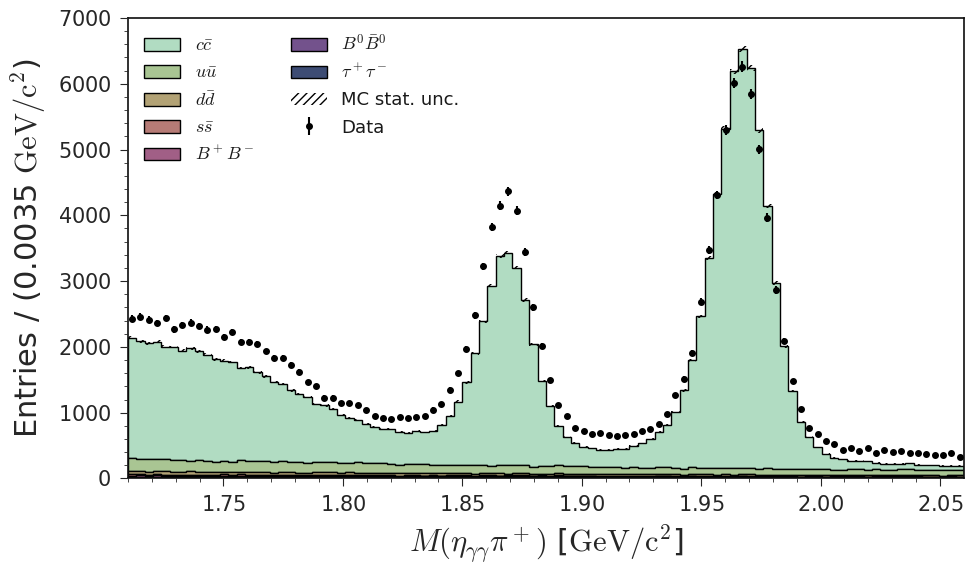

In [27]:
var = "Dp_M"
bins = (1.71, 2.06)
nbins = 100

xlabel = r"$M(\eta_{\gamma\gamma}\pi^+)$ [$\mathrm{GeV/c^2}$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto.png")
print(output)
# output = "test.png"
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins, xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg/MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_ROE_Mgg_1.png


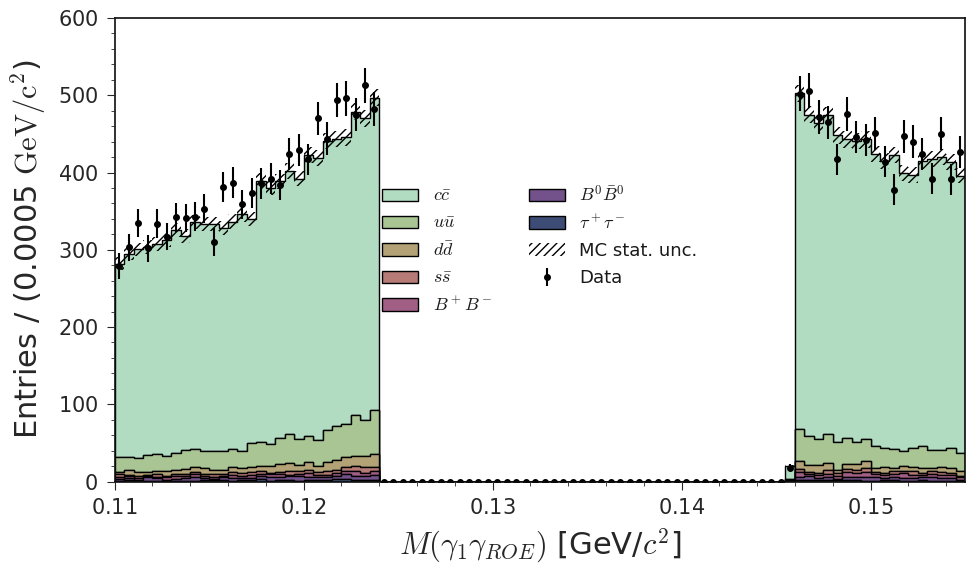

In [28]:
var = "ROE_Mgg_mask"
bins = (0.110,0.155)
nbins = 90


xlabel = r"$M(\gamma_{1}\gamma_{ROE})$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_ROE_Mgg_1.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins, xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg/MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_ROE_Mgg_2.png


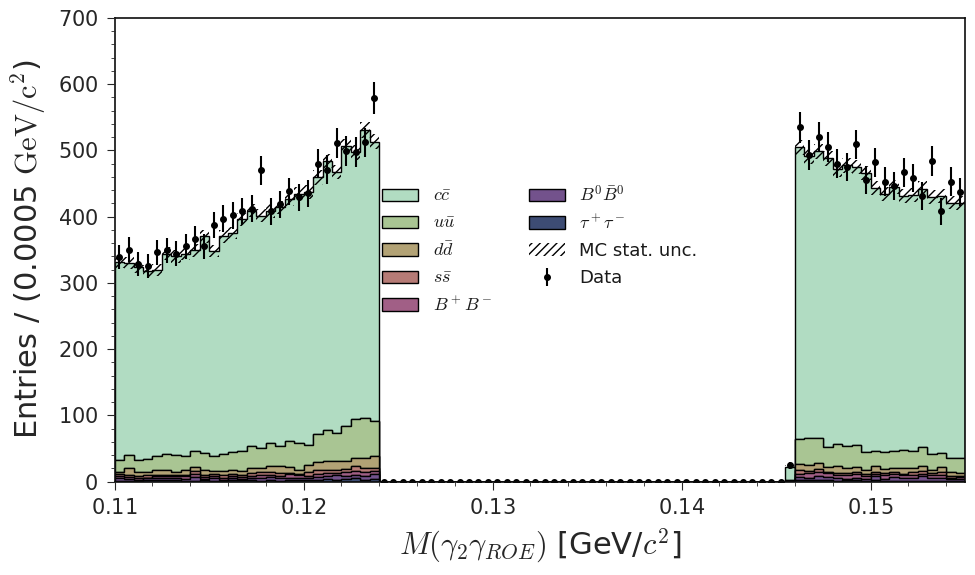

In [29]:
var = "ROE_Mgg_mask_2"
bins = (0.110,0.155)
nbins = 90

xlabel = r"$M(\gamma_{2}\gamma_{ROE})$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_ROE_Mgg_2.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins, xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg/MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_Eta_M_bf.png


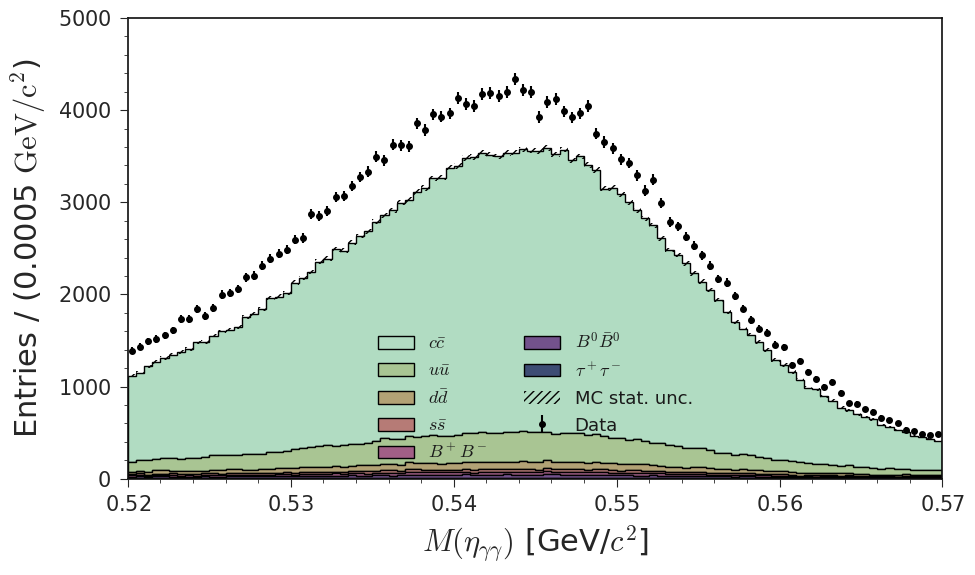

In [30]:
var = "etapip_gg_Eta_M_bf"
bins = (0.52,0.570)
nbins = 100

xlabel = r"$M(\eta_{\gamma\gamma})$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_yes_bdt_yes_pi0veto_Eta_M_bf.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins, xlabel, output)

In [20]:
def load_root_files(dir_list, tags, tree, cut, variables, bdt_cut):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            pattern = os.path.join(d,f"{tree}", "ref", "min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
            # print(pattern)
            matched_files = glob.glob(pattern)
            matched_files.sort()
            file_map[tag].extend(matched_files)
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")

    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        
        # ccbar 분리
        if tag == "ccbar":
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID==etapip_Eta_genMotherID) & (Pip_genMotherPDG==431 | Pip_genMotherPDG==-431)").copy()
            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431) | (Pip_genMotherPDG == -431))").copy()
            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_bkg"] = df_bkg.query(cut)
            dataframes["ccbar_bkg2"] = df_bkg2.query(cut)
        else:
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes


In [4]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg2', 'ccbar_bkg', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s$ signal',  r'$D^+$ signal'
]


In [14]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_gg"
cut = "Dp_M>0 & rank_Dp_chiProb==1"
variables = ["Dp_M", "ds_weight", "rank_Dp_chiProb"]
var = ["Dp_M","rank_Dp_chiProb"]
bdt_cut="0.86"

bins = (1.71, 2.06)
xlabel = r"$M(\eta_{\gamma\gamma}\pi^+)$ [$\mathrm{GeV/c^2}$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_signal_separated.png")
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
mc_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3",
    f"{mc_base}/15rd_jae_e20_b26_v1",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1",
    f"{mc_base}/15rd_jae_mori_off_v1",
]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables, bdt_cut)



ccbar: 18 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


ValueError: No objects to concatenate

/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_off_v1/etapip_gg/ref/0.86/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub04.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub01.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub03.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub05.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub02.BDT.root
/share/storage/jykim/storage_b2/storage/redu

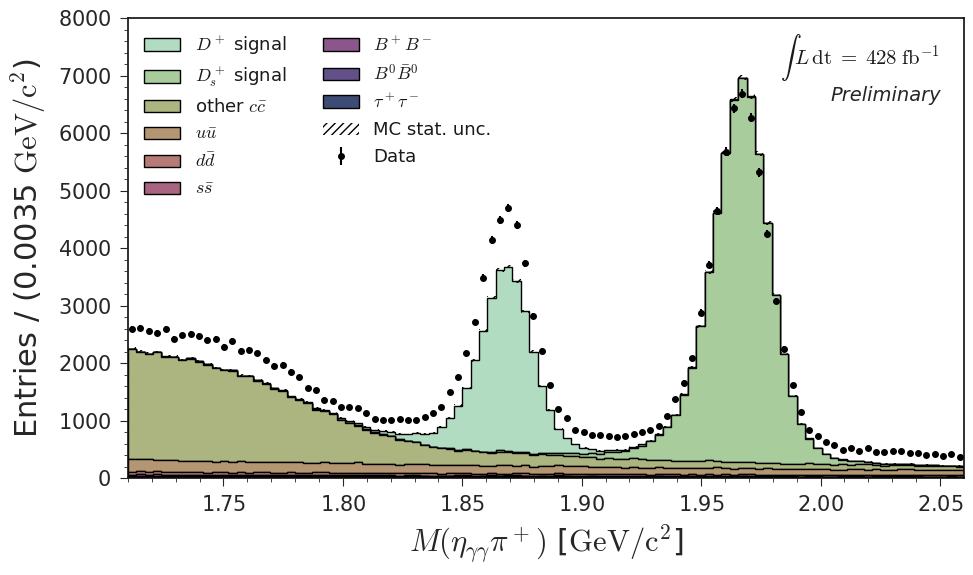

In [24]:
# 실데이터
# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7"
# data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.86" for d in [
#     "jae_13_had_4S_off_v1", "jae_13_had_4S_v3", "jae_23_had_4S_off_v1", "jae_23_had_4S_v1",
#     "jae_23_had_5Sscan_10657_v1", "jae_23_had_5Sscan_10706_v1", "jae_23_had_5Sscan_10751_v1", "jae_23_had_5Sscan_10810_v1"
# ]]
data_dirs = [
    f"{data_base}/jae_13_had_4S_off_v1",
    f"{data_base}/jae_13_had_4S_v3",
    f"{data_base}/jae_23_had_4S_off_v1",
    f"{data_base}/jae_23_had_4S_v1",
    f"{data_base}/jae_23_had_5Sscan_10657_v1",
    f"{data_base}/jae_23_had_5Sscan_10706_v1",
    f"{data_base}/jae_23_had_5Sscan_10751_v1",
    f"{data_base}/jae_23_had_5Sscan_10810_v1",
]
data_df = load_data_files(data_dirs, tree, cut, var)

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, 'Dp_M', bins, xlabel, output)

In [25]:
mc_data["ccbar_bkg"]

,Dp_M,ds_weight,rank_Dp_chiProb,Pip_mcPDG,etapip_Eta_isSignal,Pip_genMotherPDG,Pip_genMotherID,etapip_Eta_genMotherPDG,etapip_Eta_genMotherID
0,1.968506,0.291978,1.0,-211.0,1.0,-431.0,12.0,-431.0,12.0
6,1.951315,0.290267,1.0,-211.0,1.0,-431.0,15.0,-431.0,15.0
7,1.955395,0.249356,1.0,211.0,1.0,431.0,8.0,431.0,8.0
9,1.966142,0.193488,1.0,211.0,1.0,431.0,10.0,431.0,10.0
14,1.979414,0.321352,1.0,211.0,1.0,431.0,6.0,431.0,6.0
...,...,...,...,...,...,...,...,...,...
750122,1.956473,0.284665,1.0,-211.0,1.0,-431.0,19.0,-431.0,19.0
750123,1.980089,0.201109,1.0,211.0,1.0,431.0,6.0,431.0,6.0
750128,1.970165,0.271628,1.0,211.0,1.0,431.0,8.0,431.0,8.0
750134,1.966331,0.193488,1.0,-211.0,1.0,-431.0,15.0,-431.0,15.0


In [26]:
unique_values = mc_data["ccbar_bkg"]["etapip_Eta_isSignal"].unique()
print(unique_values)


[1.]


In [27]:
unique_values = mc_data["ccbar_bkg"]["Pip_genMotherPDG"].unique()
print(unique_values)

[-431.  431.]


In [28]:
unique_values = mc_data["ccbar_bkg"]["etapip_Eta_genMotherPDG"].unique()
print(unique_values)

[-431.  431.]


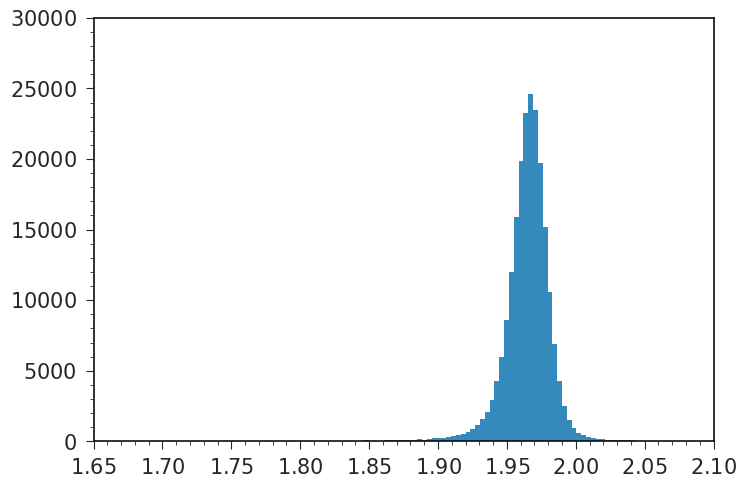

In [29]:
plt.hist(mc_data["ccbar_bkg"].Dp_M, bins=np.linspace(1.71, 2.06, 101));

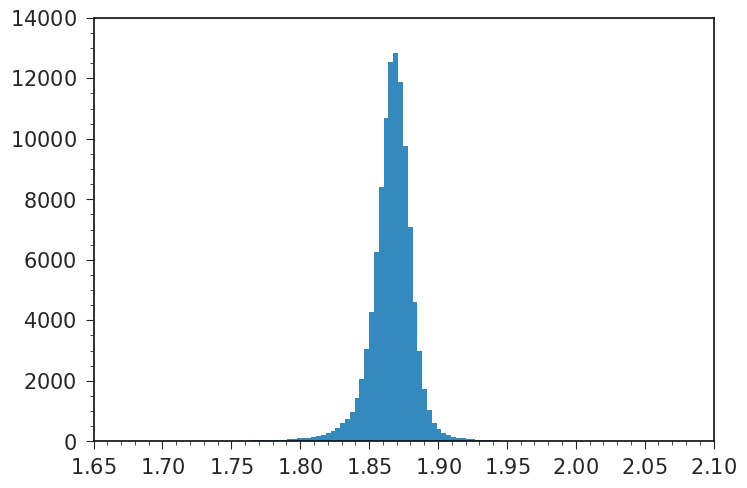

In [30]:
plt.hist(mc_data["ccbar_sig"].Dp_M, bins=np.linspace(1.71, 2.06, 101));

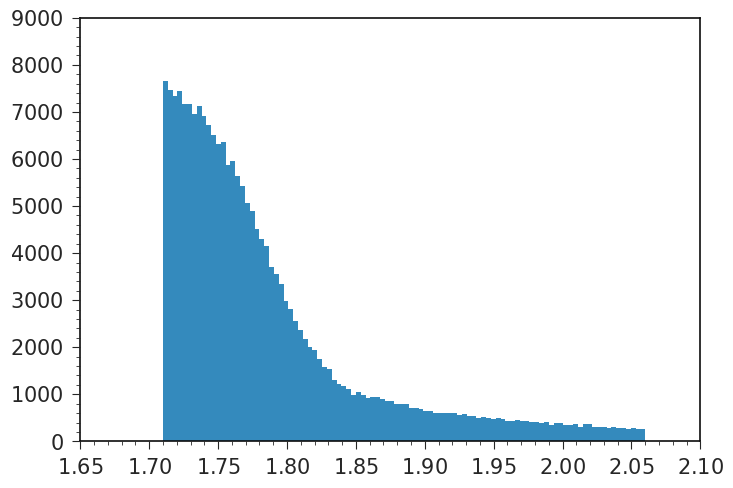

In [31]:
plt.hist(mc_data["ccbar_bkg2"].Dp_M, bins=np.linspace(1.71, 2.06, 101));

In [32]:
# separate Ds+ -> rho+ eta

In [36]:
def load_root_files(dir_topo_list, dir_list, tags, tree, cut, variables, bdt_cut):
    # file_map = {tag: [] for tag in tags}
    # for tag in tags:
    #     if tag != "ccbar":
    #         for d in dir_list:
    #             path = os.path.join(d, f"weighted_{tag}.BCS.root")
    #             if os.path.exists(path):
    #                 file_map[tag].append(path)
    #     else:
    #         for d in dir_topo_list:
    #             path = os.path.join(d, f"standard.root")
    #             if os.path.exists(path):
    #                 file_map[tag].append(path)            

    file_map = {tag: [] for tag in tags}
    for tag in tags:
        if tag != "ccbar":
            for d in dir_list:
                pattern = os.path.join(d,f"{tree}","ref", "min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
                # print(pattern)
                matched_files = glob.glob(pattern)
                matched_files.sort()
                file_map[tag].extend(matched_files)
        else:
            for d in dir_topo_list:
                path = os.path.join(d, f"standard.root")
                if os.path.exists(path):
                    file_map[tag].append(path)           


    dataframes = {}
    for tag in tags:
        # ccbar 분리
        if tag == "ccbar":
            dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_15', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID==etapip_Eta_genMotherID) & (Pip_genMotherPDG==431 | Pip_genMotherPDG==-431)").copy()
            # df_bkg = df.query("etapip_Eta_isSignal == 1 & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431) | (Pip_genMotherPDG == -431))").copy()
            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(nAllSigCascDcyBr_15 <= 0) and (Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           


            df_bkg3 = df.query("(nAllSigCascDcyBr_15 > 0 ) and (Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )").copy()
            df_bkg3["ds_weight"] = df_bkg3["ds_weight"]
            df_bkg3.drop(columns="Dp_isSignal", inplace=True)
            
            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_sig_Ds"] = df_bkg.query(cut)
            dataframes["ccbar_bkg_comb"] = df_bkg2.query(cut)
            dataframes["ccbar_bkg_rhopeta"] = df_bkg3.query(cut)
        else:
            dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes


In [37]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg_comb', 'ccbar_bkg_rhopeta', 'ccbar_sig_Ds', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s \to \rho^+ \eta$', r'$D^+_s$ signal',  r'$D^+$ signal'
]

/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg/MC15rd_etaKp_gg_ref_stack_with_data_fitv12_signal_rhopeta.png
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_off_v1/etapip_gg/ref/0.86/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub04.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub01.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub03.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_gg/ref/0.86/sub05.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc

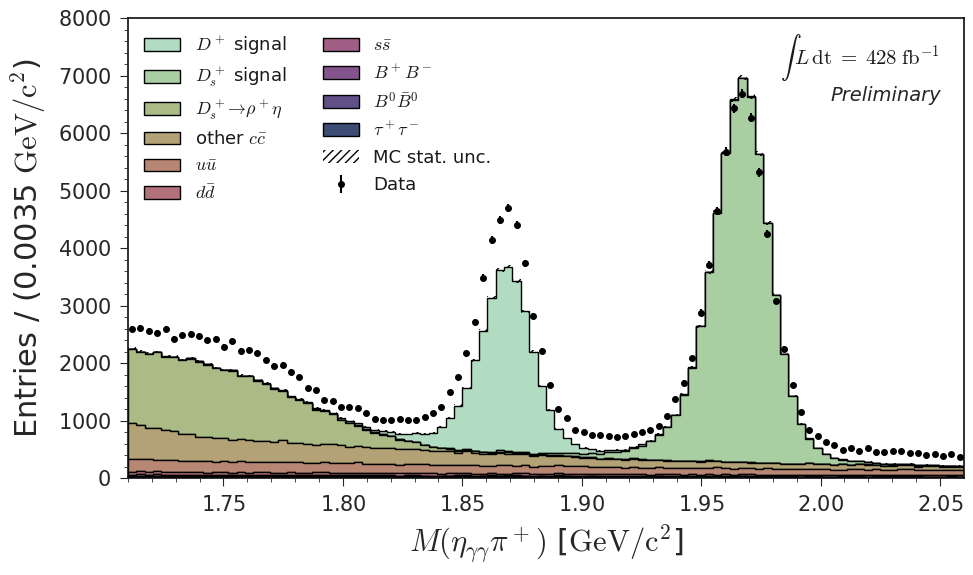

In [38]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_gg"
cut = "Dp_M>0 & rank_Dp_chiProb==1"
variables = ["Dp_M", "ds_weight", "rank_Dp_chiProb"]
var = ["Dp_M","rank_Dp_chiProb"]
bins = (1.71, 2.06)
xlabel = r"$M(\eta_{\gamma\gamma}\pi^+)$ [$\mathrm{GeV/c^2}$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_gg_ref_stack_with_data_fitv12_signal_rhopeta.png")
print(output)
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
mc_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3",
    f"{mc_base}/15rd_jae_e20_b26_v1",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1",
    f"{mc_base}/15rd_jae_mori_off_v1",
]
mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto/topo_basic_ref"
mc_topo_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e20_b26_v1/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_mori_off_v1/resultfile/result_{tree}",
]

mc_data = load_root_files(mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)

# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7"
# data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.86" for d in [
#     "jae_13_had_4S_off_v1", "jae_13_had_4S_v3", "jae_23_had_4S_off_v1", "jae_23_had_4S_v1",
#     "jae_23_had_5Sscan_10657_v1", "jae_23_had_5Sscan_10706_v1", "jae_23_had_5Sscan_10751_v1", "jae_23_had_5Sscan_10810_v1"
# ]]
data_dirs = [
    f"{data_base}/jae_13_had_4S_off_v1",
    f"{data_base}/jae_13_had_4S_v3",
    f"{data_base}/jae_23_had_4S_off_v1",
    f"{data_base}/jae_23_had_4S_v1",
    f"{data_base}/jae_23_had_5Sscan_10657_v1",
    f"{data_base}/jae_23_had_5Sscan_10706_v1",
    f"{data_base}/jae_23_had_5Sscan_10751_v1",
    f"{data_base}/jae_23_had_5Sscan_10810_v1",
]
data_df = load_data_files(data_dirs, tree, cut, var)

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, 'Dp_M', bins, xlabel, output)